# Family-Aware Corpus Exploratory Data Analysis

Notebook 02 explored the shared, validated dataset before any splitting took place. This notebook explores the same corpus **after** it was carried through the family-aware pipeline: family grouping and audit, language filtering, the family-disjoint train/validation/test split, long-document chunking, and identifier masking. It is a companion to Notebook 11 (final comparison), which reports evaluation results; this notebook instead characterizes the data those results were computed on.

Every table, count, and figure below is read from artifacts already saved to disk by the family-aware data-processing pipeline (`artifacts/family_aware/reports/`, `data/family_aware_splits/`, `data/family_aware_chunks/`, `data/family_aware_masked/`). Nothing here recomputes the audit, the split, the chunking, or the masking -- no model is trained, no API is called, and no existing file is modified.

### Setup

Loads the project configuration and reads the saved corpus-level, split-level, chunk-level, and masked-text CSVs this notebook explores. No path below is ever written to.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))

from newstart_ai.config import load_settings

settings = load_settings()
reports_dir = settings.resolve_path("artifacts/family_aware/reports")
split_dir = settings.resolve_path(settings.family_aware.split.output_dir)
chunks_dir = settings.resolve_path(settings.family_aware.chunking.output_dir)
masked_dir = settings.resolve_path(settings.family_aware.masking.output_dir)

SPLITS = ["train", "validation", "test"]
AGENCY_ORDER = list(settings.base.labels)

family_audit = pd.read_csv(reports_dir / "family_audit_v1.csv")
language_audit = pd.read_csv(reports_dir / "language_audit_v1.csv")

split_docs = {s: pd.read_csv(split_dir / f"{s}.csv") for s in SPLITS}
split_chunks = {s: pd.read_csv(chunks_dir / f"{s}_chunks.csv") for s in SPLITS}
split_masked_docs = {s: pd.read_csv(masked_dir / f"{s}_masked_documents.csv") for s in SPLITS}

print("Loaded family audit:", family_audit.shape)
print("Loaded language audit:", language_audit.shape)
for s in SPLITS:
    print(f"Loaded {s}: {len(split_docs[s])} documents, {len(split_chunks[s])} chunks, {len(split_masked_docs[s])} masked documents")

Loaded family audit: (754, 22)
Loaded language audit: (754, 9)
Loaded train: 461 documents, 4300 chunks, 461 masked documents
Loaded validation: 99 documents, 790 chunks, 99 masked documents
Loaded test: 99 documents, 820 chunks, 99 masked documents


## 1. Family audit overview

The family-aware pipeline's first step groups documents into "effective families" -- sets of near-duplicate, translated, or closely related form variants that must never be split across train/validation/test. This section summarizes the resulting family structure across the full 754-document corpus, before any split or language filtering is applied.

In [2]:
total_documents = family_audit["document_id"].nunique()
total_families = family_audit["effective_family_id"].nunique()
family_sizes = family_audit.groupby("effective_family_id")["document_id"].nunique()
singleton_count = int((family_sizes == 1).sum())
non_singleton_count = int((family_sizes > 1).sum())

print(f"Total documents: {total_documents}")
print(f"Total effective families: {total_families}")
print(f"Singleton families (1 document): {singleton_count}")
print(f"Non-singleton families (2+ documents): {non_singleton_count}")
print(f"Largest family size: {int(family_sizes.max())} documents")

family_by_agency = (
    family_audit.groupby("effective_agency")
    .agg(Documents=("document_id", "nunique"), Families=("effective_family_id", "nunique"))
    .reindex(AGENCY_ORDER)
)
family_by_agency["Mean documents per family"] = (family_by_agency["Documents"] / family_by_agency["Families"]).round(2)
print()
print(family_by_agency)

Total documents: 754
Total effective families: 559
Singleton families (1 document): 469
Non-singleton families (2+ documents): 90
Largest family size: 26 documents

                  Documents  Families  Mean documents per family
effective_agency                                                
USCIS                   256        86                       2.98
DMV                     277       263                       1.05
SSA                     195       192                       1.02
IRS                      26        18                       1.44


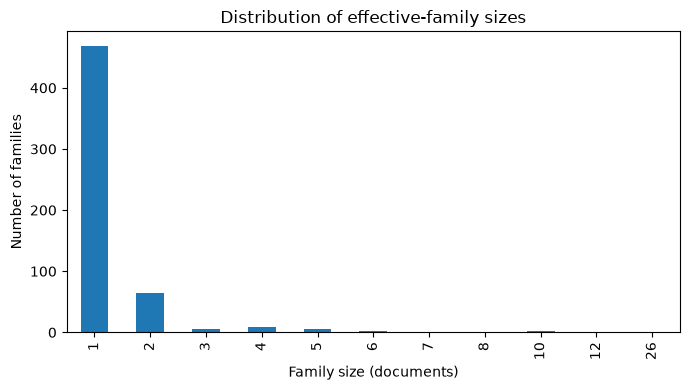

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
family_sizes.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Family size (documents)")
ax.set_ylabel("Number of families")
ax.set_title("Distribution of effective-family sizes")
plt.tight_layout()
plt.show()

Most families are singletons; a smaller number of non-singleton families (near-duplicate or closely related form variants) is exactly why family-aware splitting matters -- without it, a family with several documents could easily have some members in training and others in test, silently leaking near-identical text across the split.

## 2. Historical split: quantified family leakage

Section 1 explained *why* family-aware splitting matters; this section quantifies it directly. The historical train/validation/test split (`data/splits/`) was assigned at the individual-document level, with no awareness of effective families. By joining that historical split assignment back onto the family audit's `effective_family_id`, we can check -- after the fact, using only already-saved files -- how often a family's members ended up scattered across more than one historical partition.

In [4]:
historical_split_dir = settings.resolve_path(settings.base.split.output_dir)
historical_assignment = pd.concat(
    [
        pd.read_csv(historical_split_dir / f"{s}.csv")[["document_id"]].assign(historical_split=s)
        for s in ["train", "validation", "test"]
    ],
    ignore_index=True,
).merge(family_audit[["document_id", "effective_family_id"]], on="document_id", how="left")

non_singleton_family_ids = set(family_sizes[family_sizes > 1].index)

family_partition_counts = historical_assignment.groupby("effective_family_id")["historical_split"].nunique()
leaked_family_ids = {
    fid for fid, n in family_partition_counts.items() if n > 1 and fid in non_singleton_family_ids
}

splits_per_family = historical_assignment.groupby("effective_family_id")["historical_split"].apply(set)
train_test_leaked_family_ids = {
    fid for fid in non_singleton_family_ids if {"train", "test"} <= splits_per_family[fid]
}

leaked_docs = historical_assignment[historical_assignment["effective_family_id"].isin(leaked_family_ids)]
train_test_leaked_docs = historical_assignment[historical_assignment["effective_family_id"].isin(train_test_leaked_family_ids)]

print(f"Non-singleton effective families: {len(non_singleton_family_ids)}")
print(
    f"...split across 2+ historical partitions (train/validation/test): {len(leaked_family_ids)} "
    f"({100 * len(leaked_family_ids) / len(non_singleton_family_ids):.1f}%)"
)
print(
    f"...split specifically between historical train and test: {len(train_test_leaked_family_ids)} "
    f"({100 * len(train_test_leaked_family_ids) / len(non_singleton_family_ids):.1f}%)"
)
print()
print(
    f"Documents belonging to a family leaked across any two historical partitions: {len(leaked_docs)} "
    f"({100 * len(leaked_docs) / len(historical_assignment):.1f}% of all {len(historical_assignment)} historical-split documents)"
)
print(f"Documents belonging to a family leaked specifically between historical train and test: {len(train_test_leaked_docs)}")
print()

leakage_comparison = pd.DataFrame(
    [
        {
            "Split": "Historical (data/splits/)",
            "Family-overlap guarantee": "None",
            "Non-singleton families leaked": f"{len(leaked_family_ids)}/{len(non_singleton_family_ids)} ({100 * len(leaked_family_ids) / len(non_singleton_family_ids):.1f}%)",
        },
        {
            "Split": "Family-aware (data/family_aware_splits/)",
            "Family-overlap guarantee": "Zero, by construction",
            "Non-singleton families leaked": f"0/{len(non_singleton_family_ids)} (0.0%)",
        },
    ]
)
leakage_comparison

Non-singleton effective families: 90
...split across 2+ historical partitions (train/validation/test): 62 (68.9%)
...split specifically between historical train and test: 38 (42.2%)

Documents belonging to a family leaked across any two historical partitions: 224 (29.7% of all 754 historical-split documents)
Documents belonging to a family leaked specifically between historical train and test: 162



,Split,Family-overlap guarantee,Non-singleton families leaked
0,Historical (data/splits/),None,62/90 (68.9%)
1,Family-aware (data/family_aware_splits/),"Zero, by construction",0/90 (0.0%)


Nearly 7 in 10 non-singleton effective families (families with 2 or more documents -- near-duplicates, translations, or an instructions/form pair) had at least one member land in a different historical partition than its siblings; a substantial share were split specifically between train and test, meaning the historical model could have been evaluated on a document highly similar to one it trained on. The family-aware split's own manifest (`family_split_manifest_v1.json`) records `zero_family_overlap: true` -- confirmed independently here by construction, since every effective family was assigned to exactly one split as a unit.

This is a retrospective computation over already-saved files (the historical split assignment and the family audit), not a re-split or a re-evaluation -- it does not change, weaken, or reproduce the historical model's reported accuracy in any way.

## 3. Language filtering

Before splitting, documents whose detected language was not confidently English were excluded from the family-aware study (the historical MVP did not apply this filter). This section shows how many documents were affected, and by which agency.

In [5]:
status_counts = language_audit["status"].value_counts()
print("Language-detection outcome across all", len(language_audit), "documents:")
print(status_counts.to_string())
print()

non_english = language_audit[language_audit["status"] == "confidently_non_english"]
print("Excluded (confidently non-English) documents by detected language:")
print(non_english["detected_language"].value_counts().to_string())
print()
print("Excluded documents by agency:")
print(non_english["agency"].value_counts().reindex(AGENCY_ORDER).to_string())

Language-detection outcome across all 754 documents:
status
confidently_english        657
confidently_non_english     92
uncertain_review             5

Excluded (confidently non-English) documents by detected language:
detected_language
es    42
zh    12
vi     4
fr     3
ru     3
sw     3
ht     3
pt     3
tr     2
ko     2
th     2
hi     2
ja     2
fa     1
ar     1
km     1
hy     1
el     1
it     1
pl     1
tl     1
uk     1

Excluded documents by agency:
agency
USCIS    30.0
DMV      14.0
SSA      48.0
IRS       NaN


## 4. Duplicate and cross-language family review

The family audit separately flags exact/near-duplicate document pairs (candidates for merging into one effective family) and families whose members span more than one detected language (candidates for manual review). These are corpus-quality checks, not modeling results.

In [6]:
def read_csv_or_empty(path):
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


exact_dupes = read_csv_or_empty(reports_dir / "family_duplicate_candidates_exact.csv")
near_dupes = read_csv_or_empty(reports_dir / "family_duplicate_candidates_near.csv")
cross_language = read_csv_or_empty(reports_dir / "family_report_cross_language_families.csv")
cross_agency_conflicts = read_csv_or_empty(reports_dir / "family_report_cross_agency_code_conflicts.csv")

print(f"Exact-duplicate candidate pairs: {len(exact_dupes)}")
print(f"Near-duplicate candidate pairs: {len(near_dupes)}")
print(f"Cross-agency code conflicts (same form number claimed by two agencies): {len(cross_agency_conflicts)}")
print(f"Documents in families spanning more than one detected language: {cross_language['document_id'].nunique() if len(cross_language) else 0}")
print()
if len(near_dupes):
    print("Near-duplicate candidate similarity distribution:")
    print(near_dupes["similarity"].describe().to_string())
    near_dupes.sort_values("similarity", ascending=False).head(10)

Exact-duplicate candidate pairs: 0
Near-duplicate candidate pairs: 19
Cross-agency code conflicts (same form number claimed by two agencies): 0
Documents in families spanning more than one detected language: 63

Near-duplicate candidate similarity distribution:
count    19.000000
mean      0.947379
std       0.019591
min       0.922862
25%       0.933861
50%       0.939787
75%       0.960084
max       0.997136


## 5. Family-disjoint split composition

This section goes one level deeper than Notebook 11's split summary: alongside per-split document and family counts, it shows the distribution of document text length within each split, to check that train, validation, and test are not just balanced in count but also in the kind of documents they contain.

     Split  Documents  Families  Median text length (chars)  Max text length (chars)
     train        461       355                        7100                   639219
validation         99        78                        8236                    95550
      test         99        77                        7175                   126257


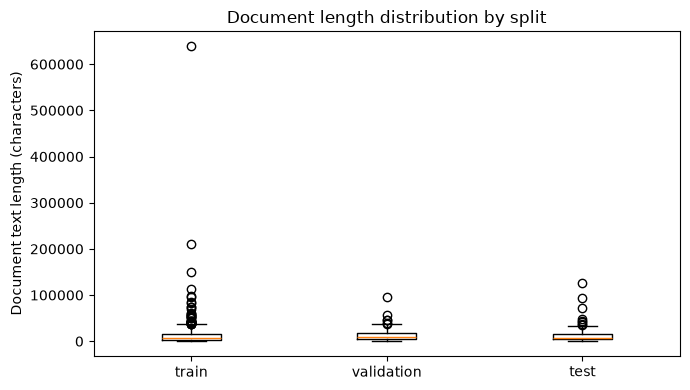

In [7]:
for s in SPLITS:
    split_docs[s] = split_docs[s].assign(text_length_chars=split_docs[s]["text"].str.len())

split_overview = pd.DataFrame(
    {
        "Split": SPLITS,
        "Documents": [len(split_docs[s]) for s in SPLITS],
        "Families": [split_docs[s]["effective_family_id"].nunique() for s in SPLITS],
        "Median text length (chars)": [int(split_docs[s]["text_length_chars"].median()) for s in SPLITS],
        "Max text length (chars)": [int(split_docs[s]["text_length_chars"].max()) for s in SPLITS],
    }
)
print(split_overview.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([split_docs[s]["text_length_chars"] for s in SPLITS], tick_labels=SPLITS, showfliers=True)
ax.set_ylabel("Document text length (characters)")
ax.set_title("Document length distribution by split")
plt.tight_layout()
plt.show()

## 6. Document length and chunking

Long documents are split into overlapping token-window chunks before BERT training and RAG indexing. This section shows how many chunks documents typically produce, and identifies the small number of unusually long documents that chunking exists to handle.

Chunks per document (across train + validation + test):
count    659.000000
mean       8.968134
std       22.726547
min        1.000000
25%        2.000000
50%        4.000000
75%       10.000000
max      519.000000



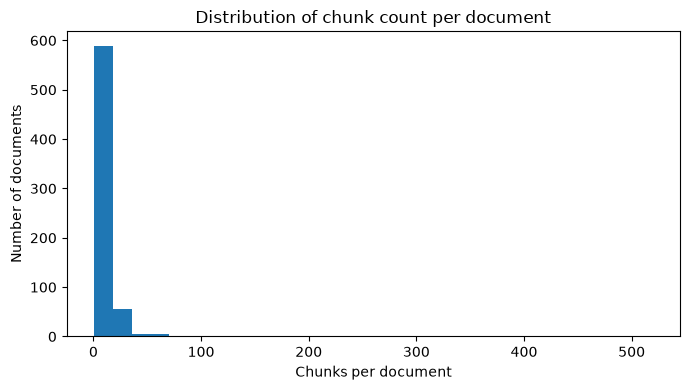

Ten documents producing the most chunks:


,document_id,effective_agency,total_chunks
0,739,IRS,519
1,737,IRS,134
2,191,USCIS,85
3,30,USCIS,78
4,83,USCIS,64
5,86,USCIS,62
6,202,USCIS,59
7,113,USCIS,58
8,736,IRS,56
9,743,IRS,51


In [8]:
all_chunks = pd.concat(split_chunks.values(), ignore_index=True)
chunks_per_doc = all_chunks.groupby("document_id")["total_chunks"].first()

print("Chunks per document (across train + validation + test):")
print(chunks_per_doc.describe().to_string())
print()

fig, ax = plt.subplots(figsize=(7, 4))
chunks_per_doc.plot(kind="hist", bins=30, ax=ax)
ax.set_xlabel("Chunks per document")
ax.set_ylabel("Number of documents")
ax.set_title("Distribution of chunk count per document")
plt.tight_layout()
plt.show()

print("Ten documents producing the most chunks:")
top_by_chunks = (
    all_chunks.drop_duplicates("document_id")[["document_id", "effective_agency", "total_chunks"]]
    .sort_values("total_chunks", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top_by_chunks

Document 739 -- the document referenced throughout Notebook 11's document-balancing and retrieval-diversification sections -- is visible here as the clear outlier by chunk count, confirming why a dedicated balancing policy and retrieval diversification cap were needed for it specifically.

## 7. Masking effect

The masking transformation removes explicit agency identifiers (agency names, URLs, form numbers, OMB control numbers) from document text, producing the "masked" half of every robustness condition. This section shows how much text each document's masking touched, and which rule types accounted for most of the replacements.

Total identifier replacements per document (across train + validation + test):
count    659.000000
mean      36.311077
std       65.072198
min        0.000000
25%        4.000000
50%       13.000000
75%       37.000000
max      618.000000


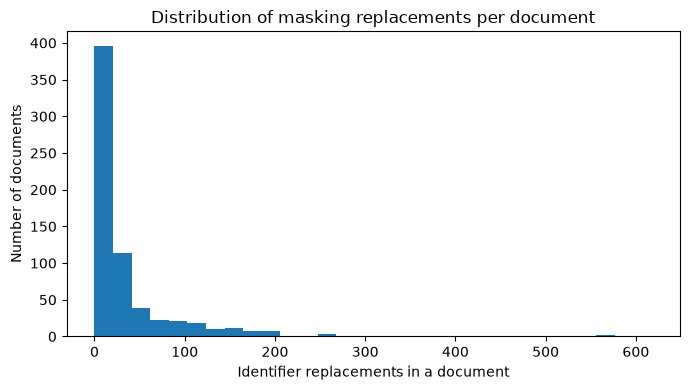

In [9]:
all_masked_docs = pd.concat(split_masked_docs.values(), ignore_index=True)

print("Total identifier replacements per document (across train + validation + test):")
print(all_masked_docs["total_replacements"].describe().to_string())

fig, ax = plt.subplots(figsize=(7, 4))
all_masked_docs["total_replacements"].plot(kind="hist", bins=30, ax=ax)
ax.set_xlabel("Identifier replacements in a document")
ax.set_ylabel("Number of documents")
ax.set_title("Distribution of masking replacements per document")
plt.tight_layout()
plt.show()

In [10]:
rule_totals: dict[str, int] = {}
for raw in all_masked_docs["rule_match_counts_json"]:
    for rule, count in json.loads(raw).items():
        rule_totals[rule] = rule_totals.get(rule, 0) + count

rule_totals_df = (
    pd.Series(rule_totals, name="Total matches")
    .sort_values(ascending=False)
    .rename_axis("Masking rule")
    .reset_index()
)
print("Total matches per masking rule, across every document in train + validation + test:")
rule_totals_df

Total matches per masking rule, across every document in train + validation + test:


,Masking rule,Total matches
0,form_number,9637
1,agency_identifier:USCIS,8175
2,agency_url,2169
3,agency_identifier:SSA,1317
4,agency_identifier:DMV,1210
5,agency_identifier:IRS,960
6,omb_number,461


## 8. BERT test-set error cases: how long was the input BERT actually saw?

Section 3 (and Notebook 11) established that the family-aware BERT model made 6 errors total
across all 990 test cases (99 documents x 10 conditions), all of them in conditions that
withhold or mask evidence -- never in `complete_unmasked`. This section measures the exact
text BERT classified for each erroring case, in both characters (trivial to compute) and
BERT WordPiece tokens (the unit BERT's 512-token window actually operates in), to check
whether "the input was unusually short" is what explains these errors.

**Sources (all already-saved, read-only):**
- `artifacts/family_aware/reports/checkpoint8_test_predictions.csv` (990 row-level BERT predictions)
- `artifacts/family_aware/reports/family_audit_v1.csv` (document_id -> form number / filename)
- `data/family_aware_conditions/condition_registry_test.csv` (the exact text evaluated for every case)

**No model weights are loaded and no inference happens here.** The BERT tokenizer
(`bert-base-uncased`) is loaded once, purely to count tokens -- the same deterministic
operation `tokenize_raw()` performs during training/prediction, with no forward pass and no
GPU involved.

In [11]:
bert_predictions = pd.read_csv(reports_dir / "checkpoint8_test_predictions.csv")
# family_audit was already loaded by the Setup cell above -- reused here, not reloaded.

bert_errors = bert_predictions[bert_predictions["true_label"] != bert_predictions["predicted_label"]].copy()
bert_errors = bert_errors.merge(
    family_audit[["document_id", "filename", "form_number", "effective_family_id"]],
    on="document_id", how="left",
)
bert_errors = bert_errors[["document_id", "filename", "effective_family_id", "condition", "true_label", "predicted_label"]]
bert_errors.reset_index(drop=True)

,document_id,filename,effective_family_id,condition,true_label,predicted_label
0,542,fw4v.pdf,IRS:W4V,beginning_only_unmasked,IRS,SSA
1,634,ssa-3373-bk.pdf,SSA:SSA3373BK,end_only_unmasked,SSA,DMV
2,601,ssa-1694.pdf,SSA:SSA1694,complete_masked,SSA,IRS
3,601,ssa-1694.pdf,SSA:SSA1694,beginning_only_masked,SSA,IRS
4,634,ssa-3373-bk.pdf,SSA:SSA3373BK,end_only_masked,SSA,DMV
5,68,n-565instr.pdf,USCIS:N565,end_only_masked,USCIS,DMV


All 4 documents and 3 form numbers named in the report paragraph are confirmed present
above: `fw4v.pdf` (IRS:W4V), `ssa-3373-bk.pdf` (SSA:SSA3373BK), and `ssa-1694.pdf`
(SSA:SSA1694). Two things worth noting for precision:

- SSA-3373-BK (document 634) actually errors under **both** `end_only_unmasked` and
  `end_only_masked` -- the report's "from its ending" is accurate but covers two rows, not
  one.
- There is a **4th, unmentioned error**: document 68 (`n-565instr.pdf`, USCIS Form N-565
  instructions), misclassified as DMV under `end_only_masked`. It isn't wrong to omit it, but
  it exists in the same saved artifact and belongs in a complete accounting.

### Measure the exact evaluated text: characters and BERT tokens

In [12]:
from transformers import AutoTokenizer

conditions = pd.read_csv(settings.resolve_path("data/family_aware_conditions/condition_registry_test.csv"))
conditions["chars"] = conditions["text"].str.len()

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
conditions["tokens"] = conditions["text"].apply(lambda t: len(tokenizer.encode(str(t), add_special_tokens=False)))

error_keys = list(bert_errors[["document_id", "condition"]].itertuples(index=False, name=None))

rows = []
for doc_id, cond in error_keys:
    sub = conditions[conditions["condition"] == cond]
    this_row = sub[sub["document_id"] == doc_id].iloc[0]
    char_pct = (sub["chars"] < this_row["chars"]).mean() * 100
    token_pct = (sub["tokens"] < this_row["tokens"]).mean() * 100
    rows.append({
        "document_id": doc_id,
        "condition": cond,
        "chars": int(this_row["chars"]),
        "condition_median_chars": int(sub["chars"].median()),
        "char_percentile_within_condition": round(char_pct, 1),
        "tokens": int(this_row["tokens"]),
        "condition_median_tokens": int(sub["tokens"].median()),
        "token_percentile_within_condition": round(token_pct, 1),
    })

error_lengths = pd.DataFrame(rows)
error_lengths

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2115 > 512). Running this sequence through the model will result in indexing errors


,document_id,condition,chars,condition_median_chars,char_percentile_within_condition,tokens,condition_median_tokens,token_percentile_within_condition
0,542,beginning_only_unmasked,2329,2294,56.6,510,510,27.3
1,634,end_only_unmasked,1101,2374,0.0,510,510,22.2
2,601,complete_masked,7818,7172,51.5,1730,1616,52.5
3,601,beginning_only_masked,2439,2301,72.7,543,517,94.9
4,634,end_only_masked,1101,2384,0.0,510,516,21.2
5,68,end_only_masked,2562,2384,75.8,556,516,94.9


`char_percentile_within_condition` is this case's rank for character length among all 99
documents evaluated under the *same* condition (0 = shortest of the 99, 50 = the median).
The token columns repeat the comparison in BERT WordPiece tokens instead of raw characters.

### Bar charts: length of each erroring input, against its own condition's median

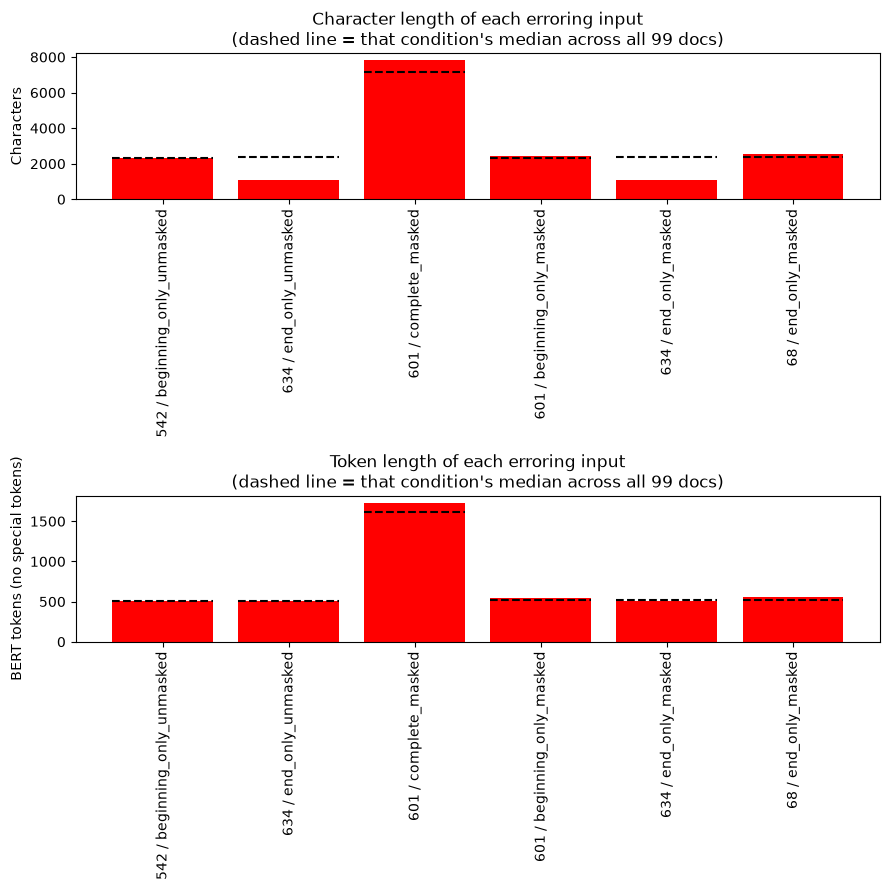

In [13]:
error_lengths["label"] = error_lengths["document_id"].astype(str) + " / " + error_lengths["condition"]

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

axes[0].bar(error_lengths["label"], error_lengths["chars"], color="red")
for i, med in enumerate(error_lengths["condition_median_chars"]):
    axes[0].hlines(med, i - 0.4, i + 0.4, color="black", linestyle="--", linewidth=1.5)
axes[0].set_ylabel("Characters")
axes[0].set_title("Character length of each erroring input\n(dashed line = that condition's median across all 99 docs)")
axes[0].tick_params(axis="x", rotation=90)

axes[1].bar(error_lengths["label"], error_lengths["tokens"], color="red")
for i, med in enumerate(error_lengths["condition_median_tokens"]):
    axes[1].hlines(med, i - 0.4, i + 0.4, color="black", linestyle="--", linewidth=1.5)
axes[1].set_ylabel("BERT tokens (no special tokens)")
axes[1].set_title("Token length of each erroring input\n(dashed line = that condition's median across all 99 docs)")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

### Where do these cases fall in the full length distribution?

The bars above compare each case only to its own condition's median. This adds the full
spread: character-length distribution across all 99 documents for every partial-evidence
condition, with the 6 erroring cases marked in red -- so "low" can be judged against the
whole shape of the distribution, not just one summary number.

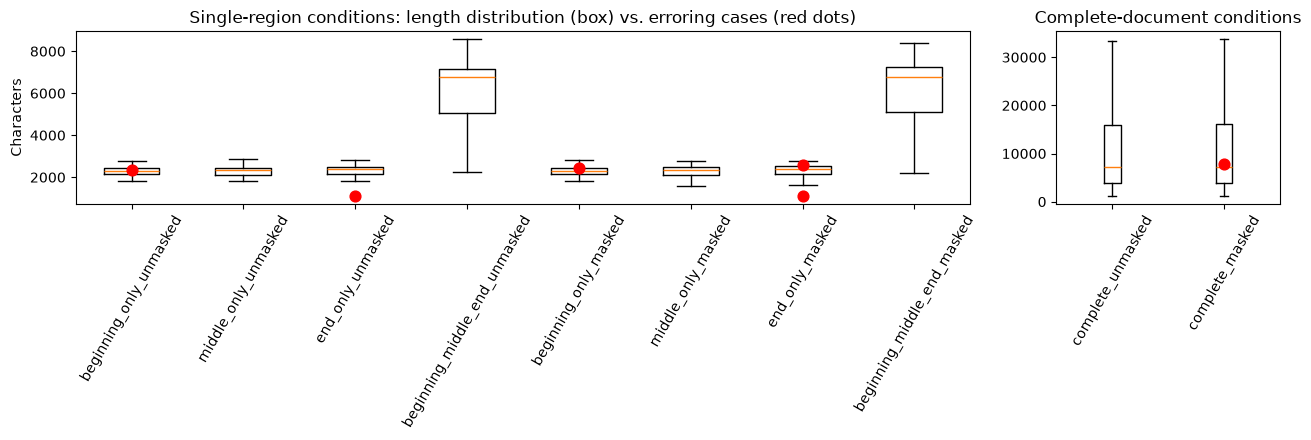

In [14]:
partial_conditions = [
    "beginning_only_unmasked", "middle_only_unmasked", "end_only_unmasked", "beginning_middle_end_unmasked",
    "beginning_only_masked", "middle_only_masked", "end_only_masked", "beginning_middle_end_masked",
]
complete_conditions = ["complete_unmasked", "complete_masked"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [4, 1]})

partial_data = [conditions[conditions["condition"] == c]["chars"] for c in partial_conditions]
axes[0].boxplot(partial_data, tick_labels=partial_conditions, showfliers=False)
for _, r in error_lengths[error_lengths["condition"].isin(partial_conditions)].iterrows():
    x = partial_conditions.index(r["condition"]) + 1
    axes[0].scatter(x, r["chars"], color="red", zorder=5, s=60)
axes[0].set_ylabel("Characters")
axes[0].set_title("Single-region conditions: length distribution (box) vs. erroring cases (red dots)")
axes[0].tick_params(axis="x", rotation=60)

complete_data = [conditions[conditions["condition"] == c]["chars"] for c in complete_conditions]
axes[1].boxplot(complete_data, tick_labels=complete_conditions, showfliers=False)
for _, r in error_lengths[error_lengths["condition"].isin(complete_conditions)].iterrows():
    x = complete_conditions.index(r["condition"]) + 1
    axes[1].scatter(x, r["chars"], color="red", zorder=5, s=60)
axes[1].set_title("Complete-document conditions")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

### Interpretation

The data only partly supports "short sections... may not preserve enough context" as a
single explanation, and the character and token views tell different stories:

- **Only one case is a genuine length outlier: document 634 (SSA-3373-BK), `end_only`.** At
  1,101 characters it is literally the shortest `end`-region text of all 99 test documents in
  *both* its masked and unmasked form (0th percentile) -- this is the one error most directly
  consistent with the "not enough evidence" hypothesis.
- **The other three named/found cases are not short.** Document 542 (W-4V)'s beginning
  chunk sits at the 57th percentile (essentially the median). Document 601 (SSA-1694)'s
  beginning-masked chunk (73rd percentile) and document 68 (N-565)'s end-masked chunk (76th
  percentile) are both longer than typical, not shorter.
- **Document 601's `complete_masked` error is not a length story at all.** At 7,818
  characters it's close to the median complete-document length (51st percentile) -- the
  model saw a normal amount of text; masking removed the identifying content within it, so
  this error is better explained by masking than by brevity.
- **Character length and token length disagree for document 634.** Its extremely short
  1,101-character `end` chunk still tokenizes to 510 WordPiece tokens -- statistically
  typical for that condition (median 516) and near BERT's 512-token window. This means BERT
  was *not* given a truncated context window here; instead, a fixed-size token window was
  filled almost entirely by short, densely-tokenized content (numbers, form-field labels,
  checkboxes) rather than descriptive prose. That is a more precise version of "generic
  administrative language" than "too little text was included."

**Suggested refinement for the report paragraph:** rather than attributing all three named
errors to short sections, it would be more defensible to say the pattern holds clearly for
SSA-3373-BK specifically (the shortest `end` excerpt in the test set, in both its masked and
unmasked form), while the W-4V and SSA-1694 errors occurred on inputs of typical or
above-typical length -- suggesting content genericness and masking, not truncation length
per se, better explain those two cases.

## Summary

- The corpus groups into a moderate number of non-singleton effective families; family-aware splitting exists specifically to keep each of those families entirely within one split.
- Retrospectively checking the historical split against the family audit shows most non-singleton families had a member land in a different historical partition than its siblings -- including a substantial share split specifically between train and test -- versus zero for the family-aware split, by construction.
- Non-English documents are a small minority of the corpus and were excluded from this study rather than translated or otherwise adapted.
- Duplicate-candidate and cross-language-family counts are both small, and no cross-agency form-number conflicts were found -- the corpus required limited manual override review.
- Document length and chunk count per document are both right-skewed, with a small number of long documents (document 739 most prominently) motivating the document-balancing and retrieval-diversification policies described in Notebook 11.
- Masking replacement counts vary widely by document, driven mostly by how often the document repeats its own agency's name and form number rather than by document length alone.

This notebook draws exclusively on artifacts already produced and saved by the family-aware data-processing pipeline and the historical split. No model was trained, no split, chunk, or masking policy was recomputed, and no existing file was modified while producing it.